In [37]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))

lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp")).to_crs(epsg=27700)
london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].rename(columns={"LSOA21CD": "lsoa_code"})

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}, lsoa_london: {lsoa_london.shape}")

Reloaded.
census_london: (4994, 4), imd_london: (4994, 10), lsoa_london: (4994, 9)


## Phase 1 — Demand Estimation Across Four Equity Scenarios

Equity-adjusted demand weight per LSOA: Dᵢ = Pᵢ × Pd × Ppub × (1 + α·IMDᵢ)
Pᵢ = driving-age population (17+), computed in 02_data_cleaning from TS007A.
IMDᵢ = income deprivation score (rate), IoD2025 File 7 'Income Score (rate)'.
Pd = 0.31, Ppub = 0.40 (DfT EV Tracker Year 1, §8.5).
α ∈ {0, 0.1, 0.3, 0.5} → Scenarios A (efficiency baseline), B (mild equity), C (moderate equity, primary), D (strong equity).
Since Pd and Ppub are constants identical across all LSOAs, they only rescale Dᵢ uniformly — the spatial ranking of demand across LSOAs is driven entirely by Pᵢ and (1 + α·IMDᵢ).

### merge demand inputs

In [38]:
demand = census_london[["lsoa_code", "lsoa_name", "driving_age_pop"]].merge(
    imd_london[["lsoa_code", "income_score", "income_decile"]], on="lsoa_code", how="left"
)

missing = demand["income_score"].isna().sum()
print(f"Merged rows: {len(demand)}, missing income_score: {missing}")
demand.head(3)

Merged rows: 4994, missing income_score: 0


,lsoa_code,lsoa_name,driving_age_pop,income_score,income_decile
0,E01000001,City of London 001A,1346,0.013,10
1,E01000002,City of London 001B,1293,0.018,10
2,E01000003,City of London 001C,1500,0.107,8


### compute D_A–D_D

In [39]:
Pd = 0.31
Ppub = 0.40
alphas = {"A": 0.0, "B": 0.1, "C": 0.3, "D": 0.5}

for label, alpha in alphas.items():
    demand[f"D_{label}"] = demand["driving_age_pop"] * Pd * Ppub * (1 + alpha * demand["income_score"])

print("=== Demand Weight Summary (D_A – D_D) ===")
print(demand[["D_A", "D_B", "D_C", "D_D"]].describe().round(2))

=== Demand Weight Summary (D_A – D_D) ===
           D_A      D_B      D_C      D_D
count  4994.00  4994.00  4994.00  4994.00
mean    174.01   178.77   188.30   197.83
std      30.91    32.18    35.22    38.79
min      96.47    98.50   101.56   104.63
25%     153.39   156.99   164.17   170.84
50%     169.14   173.52   182.77   192.14
75%     189.84   195.27   207.03   218.91
max     408.33   419.93   443.12   466.32


### sanity check — equity weighting direction

In [40]:
# D_C should correlate strongly positively with income_score (more deprived → more uplift)
# while D_A (alpha=0) has zero correlation with income_score by construction
from scipy.stats import pearsonr

r_A, _ = pearsonr(demand["income_score"], demand["D_A"])
r_C, _ = pearsonr(demand["income_score"], demand["D_C"])
print(f"Correlation income_score vs D_A (should be ≈ driven only by population, not income): {r_A:.4f}")
print(f"Correlation income_score vs D_C (should shift positive as alpha grows):              {r_C:.4f}")

Correlation income_score vs D_A (should be ≈ driven only by population, not income): 0.1089
Correlation income_score vs D_C (should shift positive as alpha grows):              0.3127


### Fig E1 — Scenario A (baseline) choropleth

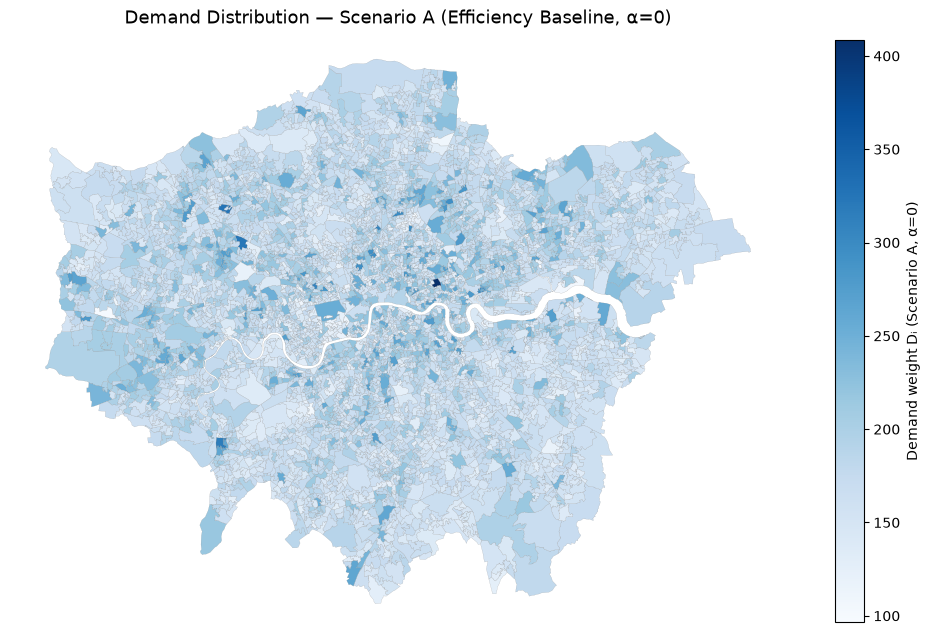

Saved: fig_demand_scenario_A.png


In [41]:
demand_map = lsoa_london[["lsoa_code", "geometry"]].merge(demand, on="lsoa_code", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
demand_map.plot(
    column="D_A", cmap="Blues", linewidth=0.1, edgecolor="grey",
    legend=True, ax=ax, legend_kwds={"label": "Demand weight Dᵢ (Scenario A, α=0)", "shrink": 0.6}
)
ax.set_title("Demand Distribution — Scenario A (Efficiency Baseline, α=0)", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_scenario_A.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_demand_scenario_A.png")

### Fig E2 — Scenario C (primary equity) choropleth

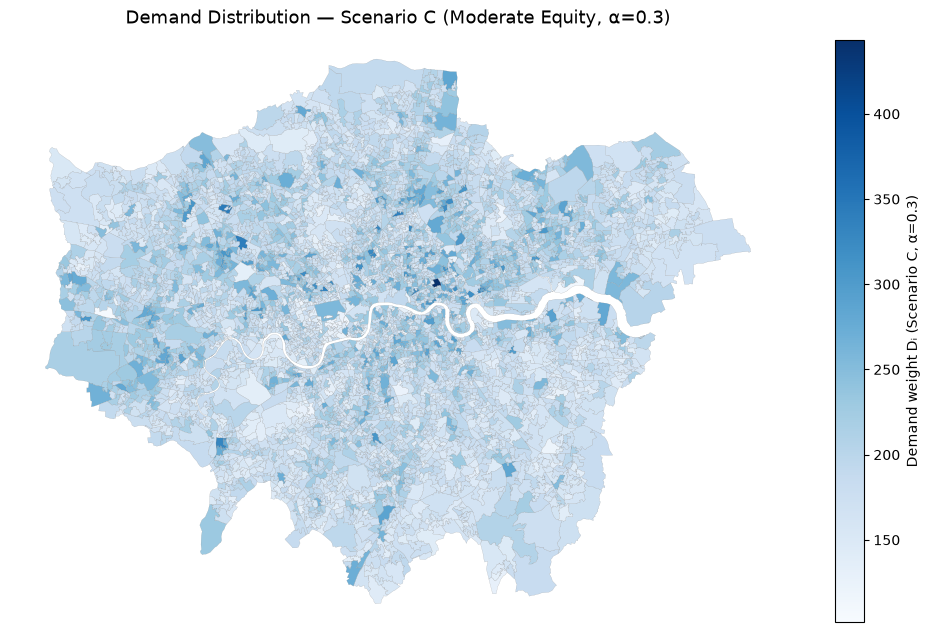

Saved: fig_demand_scenario_C.png


In [42]:
fig, ax = plt.subplots(figsize=(10, 10))
demand_map.plot(
    column="D_C", cmap="Blues", linewidth=0.1, edgecolor="grey",
    legend=True, ax=ax, legend_kwds={"label": "Demand weight Dᵢ (Scenario C, α=0.3)", "shrink": 0.6}
)
ax.set_title("Demand Distribution — Scenario C (Moderate Equity, α=0.3)", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_scenario_C.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_demand_scenario_C.png")

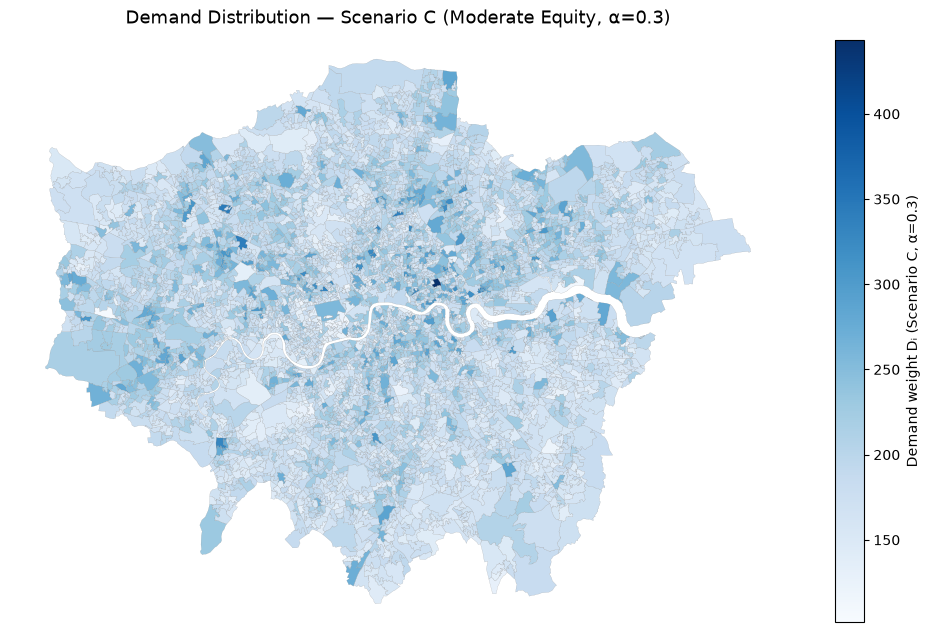

Saved: fig_demand_scenario_C.png


In [43]:
fig, ax = plt.subplots(figsize=(10, 10))
demand_map.plot(
    column="D_C", cmap="Blues", linewidth=0.1, edgecolor="grey",
    legend=True, ax=ax, legend_kwds={"label": "Demand weight Dᵢ (Scenario C, α=0.3)", "shrink": 0.6}
)
ax.set_title("Demand Distribution — Scenario C (Moderate Equity, α=0.3)", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_scenario_C.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_demand_scenario_C.png")

## Fig E3 — Demand Difference (Scenario C − Scenario A)

This is the key diagnostic figure: it isolates exactly what the equity multiplier changes about the demand surface, independent of the underlying population distribution. Positive values (warm colours) mark LSOAs that gain demand weight under equity weighting relative to the unweighted baseline — these are, by construction, the more income-deprived LSOAs. A diverging colourmap centred at zero is used since the difference can be positive or negative... actually by construction D_C ≥ D_A everywhere (income_score ≥ 0), so the difference is non-negative throughout; the colourmap still uses a sequential scale to reflect this.

### Fig E3 — difference map

D_C - D_A summary:
count    4994.00
mean       14.29
std         8.21
min         0.39
25%         7.53
50%        13.63
75%        19.87
max        50.34
Name: D_diff_C_minus_A, dtype: float64

Negative differences (should be 0, sanity check): 0


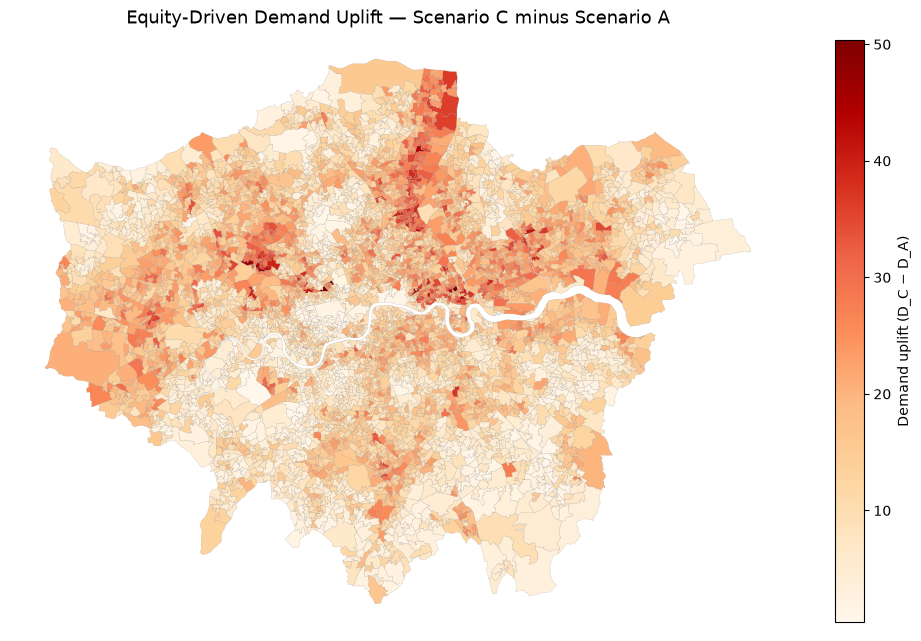

Saved: fig_demand_difference_C_minus_A.png


In [44]:
demand_map["D_diff_C_minus_A"] = demand_map["D_C"] - demand_map["D_A"]

print("D_C - D_A summary:")
print(demand_map["D_diff_C_minus_A"].describe().round(2))
print()
print("Negative differences (should be 0, sanity check):", (demand_map["D_diff_C_minus_A"] < 0).sum())

fig, ax = plt.subplots(figsize=(10, 10))
demand_map.plot(
    column="D_diff_C_minus_A", cmap="OrRd", linewidth=0.1, edgecolor="grey",
    legend=True, ax=ax, legend_kwds={"label": "Demand uplift (D_C − D_A)", "shrink": 0.6}
)
ax.set_title("Equity-Driven Demand Uplift — Scenario C minus Scenario A", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_difference_C_minus_A.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_demand_difference_C_minus_A.png")

### save demand_london.csv

In [45]:
output_path = os.path.join(BASE, "05_processed/demand_london.csv")
demand.to_csv(output_path, index=False)
print("Saved to:", output_path)
print("Shape:", demand.shape)
print("Columns:", demand.columns.tolist())

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_london.csv
Shape: (4994, 9)
Columns: ['lsoa_code', 'lsoa_name', 'driving_age_pop', 'income_score', 'income_decile', 'D_A', 'D_B', 'D_C', 'D_D']
